In [2]:
from pathlib import Path
import xarray as xr

PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")
IMERG_RAW = PROJECT / "data" / "raw" / "imerg"

supported_extensions = {
    ".nc",
    ".nc4",
    ".h5",
    ".hdf5",
    ".he5"
}

imerg_files = sorted([
    file for file in IMERG_RAW.iterdir()
    if file.is_file() and file.suffix.lower() in supported_extensions
])

print("IMERG folder:", IMERG_RAW)
print("Number of files found:", len(imerg_files))

for index, file in enumerate(imerg_files):
    print(f"[{index}] {file.name}")
    print(f"    Size: {file.stat().st_size / 1_000_000:.2f} MB")

IMERG folder: Z:\Projects\monsoon-postprocessing\data\raw\imerg
Number of files found: 1
[0] 3B-DAY.MS.MRG.3IMERG.20180702-S000000-E235959.V07B.nc4
    Size: 33.34 MB


In [3]:
from netCDF4 import Dataset

IMERG_FILE = imerg_files[0]

with Dataset(IMERG_FILE, mode="r") as root:
    groups = list(root.groups.keys())

print("Selected file:", IMERG_FILE.name)
print("Available groups:", groups)

Selected file: 3B-DAY.MS.MRG.3IMERG.20180702-S000000-E235959.V07B.nc4
Available groups: []


In [4]:
if "Grid" in groups:
    imerg_ds = xr.open_dataset(
        IMERG_FILE,
        engine="netcdf4",
        group="Grid"
    )
else:
    imerg_ds = xr.open_dataset(
        IMERG_FILE,
        engine="netcdf4"
    )

print(imerg_ds)

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2018-07-02
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB 

In [5]:
print("IMERG dataset:")
print(imerg_ds)

print("\nCoordinates:")
for name, coordinate in imerg_ds.coords.items():
    print(
        name,
        "| dimensions:", coordinate.dims,
        "| shape:", coordinate.shape
    )

print("\nData variables:")
for name, variable in imerg_ds.data_vars.items():
    print("\nVariable:", name)
    print("Dimensions:", variable.dims)
    print("Shape:", variable.shape)
    print("Units:", variable.attrs.get("units"))
    print("Long name:", variable.attrs.get("long_name"))

IMERG dataset:
<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2018-07-02
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon,

In [6]:
for coordinate_name in ["lat", "latitude", "lon", "longitude", "time"]:
    if coordinate_name in imerg_ds.coords:
        coordinate = imerg_ds[coordinate_name]

        print(f"\n{coordinate_name}:")
        print("Minimum:", coordinate.min().values)
        print("Maximum:", coordinate.max().values)
        print("Values:", coordinate.values[:5])


lat:
Minimum: -89.95
Maximum: 89.95
Values: [-89.95 -89.85 -89.75 -89.65 -89.55]

lon:
Minimum: -179.95
Maximum: 179.95
Values: [-179.95 -179.85 -179.75 -179.65 -179.55]

time:
Minimum: 2018-07-02T00:00:00.000000000
Maximum: 2018-07-02T00:00:00.000000000
Values: ['2018-07-02T00:00:00.000000000']


In [7]:
rainfall_candidates = [
    name for name in imerg_ds.data_vars
    if "precip" in name.lower() or "rain" in name.lower()
]

print("Possible rainfall variables:")
print(rainfall_candidates)

Possible rainfall variables:
['precipitation', 'precipitation_cnt', 'precipitation_cnt_cond', 'MWprecipitation', 'MWprecipitation_cnt', 'MWprecipitation_cnt_cond', 'probabilityLiquidPrecipitation']


In [8]:
imerg_rain = imerg_ds["precipitation"]

print("Dimensions:", imerg_rain.dims)
print("Units:", imerg_rain.attrs.get("units"))
print("Minimum:", float(imerg_rain.min(skipna=True)))
print("Maximum:", float(imerg_rain.max(skipna=True)))
print("Mean:", float(imerg_rain.mean(skipna=True)))

if "time" in imerg_rain.coords:
    print("Observation time:", imerg_rain.time.values)

Dimensions: ('time', 'lon', 'lat')
Units: mm/day
Minimum: 0.0
Maximum: 372.40496826171875
Mean: 2.593928337097168
Observation time: ['2018-07-02T00:00:00.000000000']


In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Select the calibrated daily precipitation variable
imerg_rain = imerg_ds["precipitation"]

# Remove the single time dimension
imerg_rain = imerg_rain.squeeze(
    dim="time",
    drop=True
)

# Standardize coordinate names
imerg_rain = imerg_rain.rename({
    "lat": "latitude",
    "lon": "longitude"
})

# Arrange dimensions consistently
imerg_rain = imerg_rain.transpose(
    "latitude",
    "longitude"
)

# Ensure coordinates are sorted before interpolation
imerg_rain = imerg_rain.sortby("latitude")
imerg_rain = imerg_rain.sortby("longitude")

imerg_rain.name = "imerg_rainfall_24h"
imerg_rain.attrs["units"] = "mm"
imerg_rain.attrs["valid_date"] = "2018-07-02"

print(imerg_rain)

<xarray.DataArray 'imerg_rainfall_24h' (latitude: 1800, longitude: 3600)> Size: 26MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1800, 3600), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 14kB -89.95 -89.85 -89.75 ... 89.85 89.95
  * longitude  (longitude) float32 14kB -179.9 -179.9 -179.8 ... 179.9 179.9
Attributes:
    units:       mm
    long_name:   Daily mean precipitation rate (combined microwave-IR) estima...
    valid_date:  2018-07-02


In [10]:
imerg_india = imerg_rain.where(
    (imerg_rain.latitude >= 6) &
    (imerg_rain.latitude <= 38) &
    (imerg_rain.longitude >= 68) &
    (imerg_rain.longitude <= 98),
    drop=True
)

print(imerg_india)
print("Shape:", imerg_india.shape)
print("Minimum:", float(imerg_india.min(skipna=True)), "mm")
print("Maximum:", float(imerg_india.max(skipna=True)), "mm")
print("Mean:", float(imerg_india.mean(skipna=True)), "mm")

<xarray.DataArray 'imerg_rainfall_24h' (latitude: 320, longitude: 300)> Size: 384kB
array([[0.        , 0.        , 0.        , ..., 0.095     , 0.54499996,
        0.545     ],
       [0.        , 0.        , 0.        , ..., 0.025     , 0.34499997,
        0.36499998],
       [0.        , 0.        , 0.        , ..., 0.055     , 0.21500002,
        0.19500002],
       ...,
       [0.        , 0.        , 0.        , ..., 8.679999  , 7.04      ,
        8.219999  ],
       [0.        , 0.        , 0.        , ..., 9.274999  , 7.955     ,
        8.145     ],
       [0.        , 0.        , 0.        , ..., 9.345     , 9.3949995 ,
        8.565     ]], shape=(320, 300), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 3kB 6.05 6.15 6.25 6.35 ... 37.75 37.85 37.95
  * longitude  (longitude) float32 1kB 68.05 68.15 68.25 ... 97.75 97.85 97.95
Attributes:
    units:       mm
    long_name:   Daily mean precipitation rate (combined microwave-IR) estima...
    valid_date:  2018

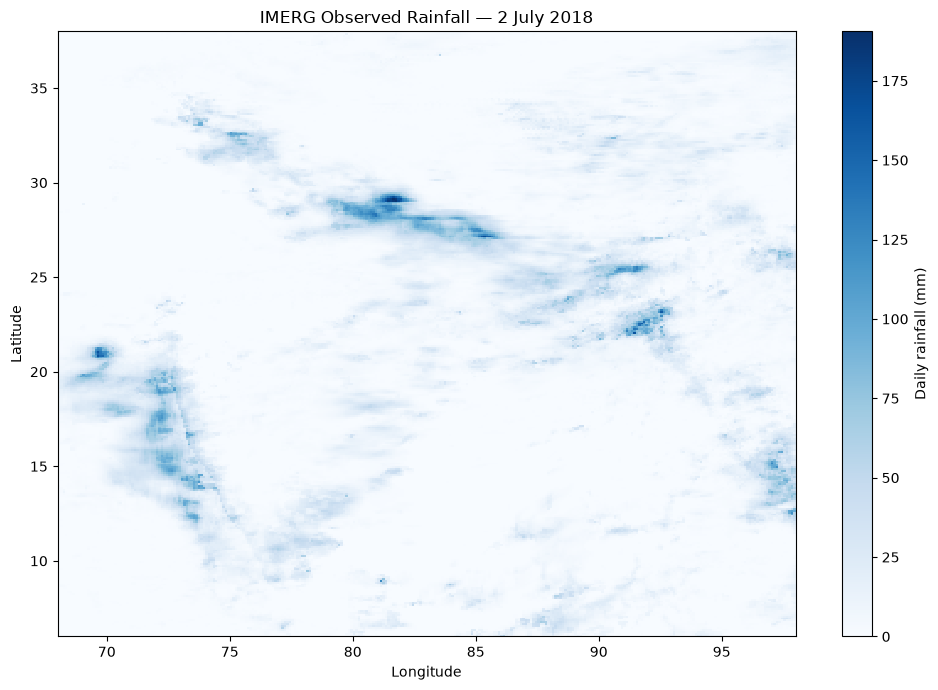

In [11]:
plt.figure(figsize=(10, 7))

imerg_india.plot(
    cmap="Blues",
    vmin=0,
    cbar_kwargs={"label": "Daily rainfall (mm)"}
)

plt.title("IMERG Observed Rainfall — 2 July 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [12]:
PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

GEFS_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "gefs_c00_20180701_f024_f048_india.nc"
)

with xr.open_dataset(GEFS_FILE) as gefs_file:
    gefs_rain = gefs_file["rainfall_24h"].load()

gefs_rain = gefs_rain.sortby("latitude")
gefs_rain = gefs_rain.sortby("longitude")

print(gefs_rain)
print("GEFS shape:", gefs_rain.shape)

<xarray.DataArray 'rainfall_24h' (latitude: 129, longitude: 121)> Size: 62kB
array([[ 2.97      ,  1.5800002 ,  0.83000004, ..., 13.8       ,
        16.9       , 10.900001  ],
       [ 3.01      ,  2.25      ,  2.06      , ...,  4.8       ,
         6.3       ,  3.7       ],
       [ 5.9200006 ,  4.9199996 ,  3.4499998 , ...,  0.2       ,
         2.2       ,  0.61      ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78000003,
         0.93      ,  1.23      ],
       [ 0.        ,  0.        ,  0.        , ...,  1.45      ,
         2.5       ,  2.9699998 ],
       [ 0.        ,  0.        ,  0.        , ...,  5.57      ,
         9.61      , 11.06      ]], shape=(129, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude  (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number     int64 8B 0
    time       datetime64[ns] 8B 2018-07-01
    surface    float64 8B 0.0
Attributes:


In [13]:
imerg_on_gefs = imerg_india.interp(
    latitude=gefs_rain.latitude,
    longitude=gefs_rain.longitude,
    method="linear"
)

imerg_on_gefs.name = "observed_rainfall_24h"
imerg_on_gefs.attrs = {
    "long_name": "IMERG rainfall interpolated to GEFS grid",
    "units": "mm",
    "valid_date": "2018-07-02",
    "interpolation": "linear"
}

print(imerg_on_gefs)
print("GEFS shape:", gefs_rain.shape)
print("IMERG matched shape:", imerg_on_gefs.shape)

<xarray.DataArray 'observed_rainfall_24h' (latitude: 129, longitude: 121)> Size: 125kB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,  0.        ,  0.        , ...,  0.02      ,
         0.055     ,         nan],
       [        nan,  0.        ,  0.01625   , ...,  0.67124996,
         1.07999995,         nan],
       ...,
       [        nan,  0.        ,  0.        , ..., 14.93250036,
        13.97999954,         nan],
       [        nan,  0.        ,  0.        , ...,  9.12000036,
         8.67999935,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(129, 121))
Coordinates:
  * latitude   (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude  (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number     int64 8B 0
    time       datetime64[ns] 8B 2018-07-01
    surface    float64 8B 0.0
Attributes:
    l

In [14]:
forecast_error = gefs_rain - imerg_on_gefs

forecast_error.name = "forecast_error"
forecast_error.attrs = {
    "long_name": "GEFS minus IMERG rainfall",
    "units": "mm"
}

print(forecast_error)

<xarray.DataArray 'forecast_error' (latitude: 129, longitude: 121)> Size: 125kB
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,   2.25      ,   2.05999994, ...,   4.78000019,
          6.24500019,          nan],
       [         nan,   4.9199996 ,   3.43374981, ...,  -0.47124996,
          1.12000009,          nan],
       ...,
       [         nan,   0.        ,   0.        , ..., -14.15250033,
        -13.04999954,          nan],
       [         nan,   0.        ,   0.        , ...,  -7.67000031,
         -6.17999935,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan]], shape=(129, 121))
Coordinates:
  * latitude   (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude  (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number     int64 8B 0
    time       datetime64[ns] 8B 2018-07-01
    surface    flo

In [15]:
forecast_values = gefs_rain.values
observed_values = imerg_on_gefs.values

valid = (
    np.isfinite(forecast_values) &
    np.isfinite(observed_values)
)

forecast_valid = forecast_values[valid]
observed_valid = observed_values[valid]

errors = forecast_valid - observed_valid

rmse = np.sqrt(np.mean(errors ** 2))
mae = np.mean(np.abs(errors))
bias = np.mean(errors)

if (
    np.std(forecast_valid) > 0 and
    np.std(observed_valid) > 0
):
    correlation = np.corrcoef(
        forecast_valid,
        observed_valid
    )[0, 1]
else:
    correlation = np.nan

print("Valid grid cells:", len(errors))
print(f"RMSE: {rmse:.2f} mm")
print(f"MAE: {mae:.2f} mm")
print(f"Mean bias: {bias:.2f} mm")
print(f"Spatial correlation: {correlation:.3f}")

Valid grid cells: 15113
RMSE: 21.38 mm
MAE: 11.62 mm
Mean bias: 5.95 mm
Spatial correlation: 0.481


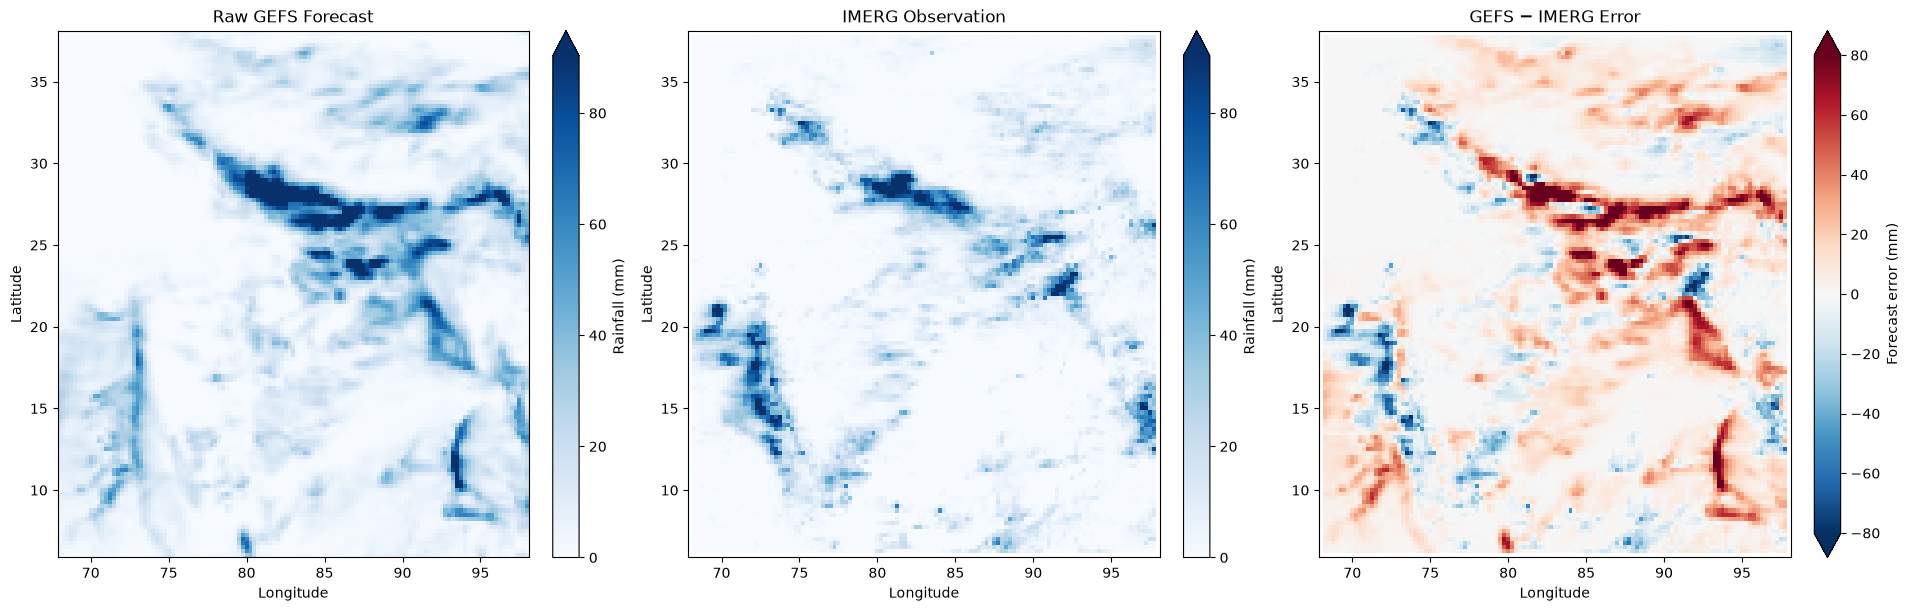

In [16]:
comparison_max = float(
    np.nanpercentile(
        np.concatenate([
            forecast_valid,
            observed_valid
        ]),
        99
    )
)

error_limit = float(
    np.nanpercentile(
        np.abs(errors),
        99
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6),
    constrained_layout=True
)

gefs_rain.plot(
    ax=axes[0],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max,
    cbar_kwargs={"label": "Rainfall (mm)"}
)
axes[0].set_title("Raw GEFS Forecast")

imerg_on_gefs.plot(
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max,
    cbar_kwargs={"label": "Rainfall (mm)"}
)
axes[1].set_title("IMERG Observation")

forecast_error.plot(
    ax=axes[2],
    cmap="RdBu_r",
    vmin=-error_limit,
    vmax=error_limit,
    cbar_kwargs={"label": "Forecast error (mm)"}
)
axes[2].set_title("GEFS − IMERG Error")

for axis in axes:
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")

plt.show()

In [17]:
COMPARISON_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "gefs_imerg_comparison_20180702.nc"
)

comparison_ds = xr.Dataset({
    "gefs_rainfall": gefs_rain,
    "imerg_rainfall": imerg_on_gefs,
    "forecast_error": forecast_error
}).load()

comparison_ds.attrs = {
    "date": "2018-07-02",
    "forecast_initialization": "2018-07-01 00 UTC",
    "forecast_lead_period": "24-48 hours",
    "observation_source": "NASA GPM IMERG Final",
    "error_definition": "GEFS minus IMERG"
}

comparison_ds.to_netcdf(
    COMPARISON_FILE,
    mode="w",
    engine="netcdf4"
)

print("Saved:", COMPARISON_FILE.exists())
print("Location:", COMPARISON_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\gefs_imerg_comparison_20180702.nc
